In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl

In [3]:
# import CellTable_CleanCohort/neighbours_matrix_pretreatment.pkl
# using pkl 
pkl_file = 'CellTable_CleanCohort/neighbours_matrix_pretreatment.pkl'
with open(pkl_file, 'rb') as f:
    neighbors_pretreatment = pkl.load(f)

pkl_file = 'CellTable_CleanCohort/neighbours_matrix_nonresponders.pkl'
with open(pkl_file, 'rb') as f:
    neighbors_nonresponders = pkl.load(f)

In [4]:
# load metadata
metadata = pd.read_csv('CellTable_CleanCohort/CleanCohort_Metadata.csv', index_col=0)

In [5]:
# display metadata contents for user overview
metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch
LEAP_ID,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1
LEAP002,Resection,FALSE,post,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1
LEAP004,Resection,FALSE,post,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP146,Core,Cycle2,mid-late,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7
LEAP147,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,53,7
LEAP148,Core,Cycle1,mid-early,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,53,7


In [6]:
# convert from dict to dataframe using keys as index, first column is everything before the first underscore of the key
pretreat_keys = neighbors_pretreatment.keys()
nonresp_keys = neighbors_nonresponders.keys()

pretreat_df = pd.DataFrame(pretreat_keys, columns=['Sample_ID'])
nonresp_df = pd.DataFrame(nonresp_keys, columns = ['Sample_ID'])

In [7]:
# strip the Sample_ID to get the first part before the underscore
pretreat_df['stripped_ID'] = pretreat_df['Sample_ID'].str.split('_').str[0]
nonresp_df['stripped_ID'] = nonresp_df['Sample_ID'].str.split('_').str[0]


In [8]:
# capitalize all letters in stripped_ID
pretreat_df['stripped_ID'].isin(metadata.index)
pretreat_df['stripped_ID'] = pretreat_df['stripped_ID'].str.upper()
nonresp_df['stripped_ID'].isin(metadata.index)
nonresp_df['stripped_ID'] = nonresp_df['stripped_ID'].str.upper()

In [9]:
# some sample_IDs have an letter appended for a different fov, so we need to correct these
pretreat_df['stripped_ID'].isin(metadata.index)
# print the ones that aren't in it - this is a naming issue resolved in the next cells
print(pretreat_df[~pretreat_df['stripped_ID'].isin(metadata.index)])

       Sample_ID stripped_ID
1    Leap084a_11    LEAP084A
85    Leap084a_1    LEAP084A
94    Leap084a_5    LEAP084A
163   Leap084a_2    LEAP084A
197   Leap084a_8    LEAP084A
337   Leap084a_3    LEAP084A
368  Leap084a_10    LEAP084A
422   Leap084a_4    LEAP084A
533   Leap084a_7    LEAP084A
547   Leap084a_9    LEAP084A
622   Leap084a_6    LEAP084A


In [10]:
# none of these in the nonresponders
print(nonresp_df[~nonresp_df['stripped_ID'].isin(metadata.index)])

Empty DataFrame
Columns: [Sample_ID, stripped_ID]
Index: []


In [11]:
# for any entry in stripped_ID that ends in A, remove the A at the end
pretreat_df['stripped_ID'] = pretreat_df['stripped_ID'].str.rstrip('A')

In [12]:
# now all stripped_IDs should be in metadata
print(pretreat_df[~pretreat_df['stripped_ID'].isin(metadata.index)])

Empty DataFrame
Columns: [Sample_ID, stripped_ID]
Index: []


In [13]:
# from pretreat_df drop LEAP IDs 145, 148, 150 which are not pre but cycle 1 samples
pretreat_df = pretreat_df[~pretreat_df['stripped_ID'].isin(['LEAP145', 'LEAP148', 'LEAP150'])]
#from non-resp_dfdrop leap ID 149 and 150 wrongly labelled as non-responder
nonresp_df = nonresp_df[~nonresp_df['stripped_ID'].isin(['LEAP149', 'LEAP150'])]

In [14]:
pretreat_df
# check in metadata to confirm that all entries in stripped_ID correspond to pretreatment samples
metadata[metadata.index.isin(pretreat_df['stripped_ID'])]['Sample_Type_(pre/post treatment)'].value_counts()

Sample_Type_(pre/post treatment)
pre    67
Name: count, dtype: int64

In [15]:
# check in metadata to confirm that all entries in stripped_ID correspond to non-responder samples
metadata[metadata.index.isin(nonresp_df['stripped_ID'])]['Sample_Type_(pre/post treatment)'].value_counts()

Sample_Type_(pre/post treatment)
pre     25
post    21
Name: count, dtype: int64

In [16]:
# print an overview of the metadata columns
metadata.columns

Index(['Biopsy_(Core/Resection)', 'FORCE_cycle',
       'Sample_Type_(pre/post treatment)', 'NACT_Treatment _Group',
       'Response_pCR', 'RCB_Scores', 'RCB_Group', 'Tissue_Format',
       'Extreme_NR', 'FORCE', 'Response', 'Patient_ID', 'Stain_Batch'],
      dtype='object')

In [17]:
# define the metadata for pretreatment and non-responders
pretreat_metadata = metadata[metadata.index.isin(pretreat_df['stripped_ID'])]
nonresp_metadata = metadata[metadata.index.isin(nonresp_df['stripped_ID'])]

In [18]:
# create a dictionary with the leapID as key and the corresponding ROIs as value
pretreat_dict = {}
for i in range(len(pretreat_metadata)):
    leapID = pretreat_metadata.index[i]
    rois = pretreat_df[pretreat_df['stripped_ID']==leapID]['Sample_ID'].values
    pretreat_dict[leapID] = rois

In [19]:
nonresp_dict = {}
for i in range(len(nonresp_metadata)):
    leapID = nonresp_metadata.index[i]
    #print(leapID)
    rois = nonresp_df[nonresp_df['stripped_ID']==leapID]['Sample_ID'].values
    nonresp_dict[leapID] = rois

In [20]:
# example of how to access the neighbors matrix for a specific sample
neighbors_pretreatment[pretreat_dict["LEAP011"][0]].loc['Antigen presenting cell','B cell']

np.float64(1.625991665642539)

In [21]:
# function to generate pairwise information for a given celltype1 and celltype2
# this function will return a dataframe with the enrichment of celltype1 and celltype2 for each sample in the sampledict
def gen_pairwise_info(celltype1, celltype2, sampledict, neighbor_matrix_dict):
    pw_info = {}
    for key in sampledict:
        matches = 0
        total = 0
        for i in range(len(sampledict[key])):
            # check if celltype1 and celltype2 are in the columns of neighborhoods[sampledict[key][i]]

            if celltype1 in neighbor_matrix_dict[sampledict[key][i]].columns:
                if celltype2 in neighbor_matrix_dict[sampledict[key][i]].columns:
                    val = neighbor_matrix_dict[sampledict[key][i]].loc[celltype1, celltype2]
                    total += val
                    matches += 1
        if matches == 0:
            print("NULL")
            print(key)
            x = 0 
        else: 
            x = total/matches
        pw_info[key] = x
    # return pw_info
    return pd.DataFrame.from_dict(pw_info, orient="index", columns = ["enrichment"])

In [22]:
# Example usage of the function
y = gen_pairwise_info("Neutrophil","Monocyte",pretreat_dict, neighbors_pretreatment)
y

NULL
LEAP092


,enrichment
LEAP001,0.190718
LEAP003,0.095624
LEAP005,-0.114628
LEAP008,-0.200170
LEAP009,2.188790
...,...
LEAP137,0.378931
LEAP142,0.198052
LEAP144,-0.941975
LEAP147,-0.274782


In [23]:
# add the enrichment information to the pretreat_metadata dataframe
pretreat_metadata['enrichment_Neutrophil_Monocyte'] = y['enrichment']

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/3243024540.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_Neutrophil_Monocyte'] = y['enrichment']


<Axes: xlabel='Response', ylabel='enrichment_Neutrophil_Monocyte'>

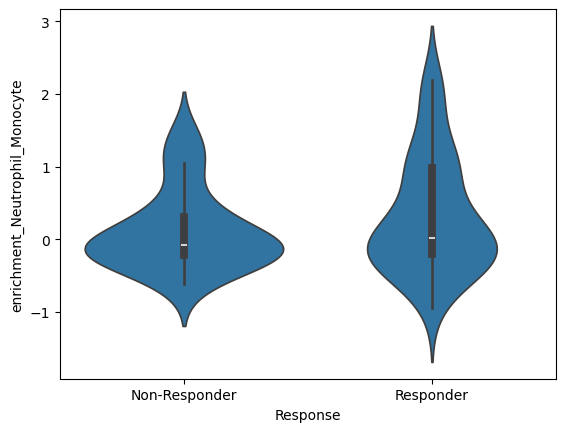

In [ ]:
# example violin plot enrichment_Neutrophil_Monocyte split by "Response"
sns.violinplot(
    x='Response',
    y='enrichment_Neutrophil_Monocyte',
    data=pretreat_metadata,
    inner='box'  # or 'point' or None
)

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2205378642.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Response'] = df['Response'].astype('category')
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2205378642.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


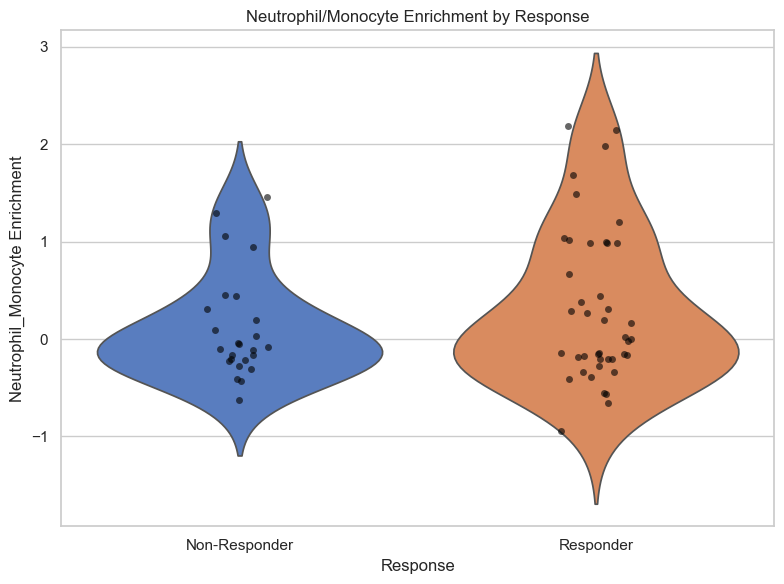

In [30]:
# Example of a violin plot with individual data points overlayed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: load your DataFrame
# df = pd.read_csv("your_data.csv", index_col=0)
df = pretreat_metadata

# Clean column names if necessary
df.columns = df.columns.str.strip()

# Ensure 'Response' is categorical
df['Response'] = df['Response'].astype('category')

# Set plot style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(8, 6))

# Draw the violin plot
sns.violinplot(
    x='Response',
    y='enrichment_Neutrophil_Monocyte',
    data=df,
    inner=None,           # No inner boxplot for clarity
    palette='muted'
)

# Overlay individual data points
sns.stripplot(
    x='Response',
    y='enrichment_Neutrophil_Monocyte',
    data=df,
    color='black',
    size=5,
    jitter=True,         # Jitter helps avoid overlapping points
    alpha=0.6
)

# Add titles and axis labels
plt.title('Neutrophil/Monocyte Enrichment by Response')
plt.xlabel('Response')
plt.ylabel('Neutrophil_Monocyte Enrichment')

# Display the plot
plt.tight_layout()
plt.show()


In [26]:
# check if Nans in any of the entries of roi
rois = pretreat_df['Sample_ID'].values
for i in range(len(rois)):
    if np.isnan(neighbors_pretreatment[rois[i]]).any().any():
        print('NAN in mm')
        print(i)
        print(rois[i])
        print('---')

In [27]:
np.isnan(neighbors_pretreatment[rois[0]]).any().any()

np.False_

In [28]:
# CD8 T cells and proliferative cancer cells co-locate more in non-responders
# Memory CD4 T cells and CD8 T cells co-locate more in responders 
# Cancer cells and macrophage+HLA cells co-locate more in non-responders
# B7H4 proliferative cells are closer to non-proliferative cancer cells in responders
nonresp_color = "#70221C"
resp_color = "#306E28"
palette_response = sns.color_palette([nonresp_color, resp_color])

In [31]:
# see that so far the metadata only has the enrichment for Neutrophil and Monocyte
pretreat_metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch,enrichment_Neutrophil_Monocyte
LEAP_ID,,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,0.190718
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1,0.095624
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1,-0.114628
LEAP008,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,True,False,Responder,4,1,-0.200170
LEAP009,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,False,Responder,5,1,2.188790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP137,Core,Diagnostic,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,True,Responder,53,6,0.378931
LEAP142,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,50,7,0.198052
LEAP144,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7,-0.941975


In [32]:
# example of how to access the neighbors matrix for a specific sample
neighbors_pretreatment['Leap084a_11']

,Antigen presenting cell,B cell,B7H4 Cancer cell,B7H4 Cancer cell Prol,CD8 T cell,Cancer cell,Cancer cell Prol,Cl Monocyte,Endothelial cell,Fibroblast,Int Monocyte,Macrophage,Macrophage + HLA,Macrophage M2,Memory CD4 T cell,Memory CD8 T cell,Monocyte,NK/CD8,Neutrophil,Regulatory T cell
Antigen presenting cell,10.862703,-0.868617,-2.170995,-1.439506,-10.524000,-2.697106,-6.381505,0.035029,6.602035,4.429255,-0.992296,10.034828,5.375831,2.236877,5.975487,-7.459652,0.097472,5.234729,-1.459262,-0.563924
B cell,-0.861899,5.400224,0.121120,0.801211,-4.710660,-2.500657,-1.923210,0.841829,1.908506,0.844533,-0.490669,0.658449,-1.179956,0.543623,2.567688,-2.267817,3.729436,3.877343,-0.720075,-0.299225
B7H4 Cancer cell,-1.905066,0.117519,4.568868,2.211486,0.904615,2.883565,2.791289,1.480071,-2.395049,-2.185939,0.990821,0.148307,0.987912,-0.006156,-1.538222,-2.626877,-0.597588,-1.434576,1.284052,-0.328034
B7H4 Cancer cell Prol,-1.468675,0.802163,1.483060,1.162426,1.741311,-1.726472,0.358357,3.737260,-1.053311,-2.544957,-0.339792,0.061165,0.200390,-0.520425,-1.385595,0.917984,-0.337292,-1.707801,-0.497499,-0.187608
CD8 T cell,-10.850181,-4.462753,1.071622,1.355299,28.795522,-4.968682,1.397344,0.868810,-10.394380,-19.701588,-0.896181,-13.105924,-4.137224,-2.088732,-7.763781,-2.882242,2.161866,-8.702604,-2.612638,0.820902
Cancer cell,-2.790916,-2.904449,2.819827,-1.979785,-4.990001,7.221096,10.390803,1.333857,-5.967727,-8.169022,4.287573,-3.814142,-2.275768,-1.459848,-3.796474,7.423482,-0.258542,-4.313581,-0.867500,-1.154072
Cancer cell Prol,-6.606265,-1.924983,2.593038,0.645539,0.922115,10.459091,9.360954,0.280913,-6.145656,-10.650403,-0.107185,-7.995521,-2.401730,-1.263458,-3.892927,5.900402,-0.856335,-4.609816,-1.286263,0.297773
Cl Monocyte,0.032417,0.825402,1.488952,3.764254,1.070150,1.711390,0.281623,-0.180538,-1.031004,-0.386998,-0.180080,-0.715359,-0.549012,-0.328698,-0.787963,-1.003105,5.786429,-0.060840,-0.326270,-0.149983
Endothelial cell,7.512169,2.291562,-2.442171,-1.050394,-10.114746,-5.688289,-5.925168,-1.039287,25.151910,9.843355,-0.743221,1.828225,0.785970,3.216510,8.648510,-4.031761,-0.718975,4.267636,-1.025135,-0.404306
Fibroblast,4.529386,1.189532,-2.720987,-2.570235,-19.332142,-8.339795,-10.664951,0.047870,10.273806,32.626491,-0.605863,4.828379,-0.421453,-0.356534,1.247124,-6.676861,-1.140582,3.397263,3.508480,-1.017522


In [33]:
# generate pairwise information for the other cell selected types and add to the metadata
pretreat_metadata['enrichment_CD8_cancerprolif'] = gen_pairwise_info("CD8 T cell","Cancer cell Prol",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_CD4_CD8'] = gen_pairwise_info("CD8 T cell","Memory CD4 T cell",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_cancer_macroHLA'] = gen_pairwise_info("Macrophage + HLA","Cancer cell",pretreat_dict, neighbors_pretreatment)
pretreat_metadata['enrichment_b7h4_cancer'] = gen_pairwise_info("B7H4 Cancer cell","Cancer cell",pretreat_dict, neighbors_pretreatment)



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2297791384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_CD8_cancerprolif'] = gen_pairwise_info("CD8 T cell","Cancer cell Prol",pretreat_dict, neighbors_pretreatment)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2297791384.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pretreat_metadata['enrichment_CD4_CD8'] = gen_pairwise_info("CD8 T cell","Memory CD4 T cell",pretreat_dict, neighbor

In [34]:
# now the metadata has the enrichment for more cell types we are interested in
pretreat_metadata

,Biopsy_(Core/Resection),FORCE_cycle,Sample_Type_(pre/post treatment),NACT_Treatment _Group,Response_pCR,RCB_Scores,RCB_Group,Tissue_Format,Extreme_NR,FORCE,Response,Patient_ID,Stain_Batch,enrichment_Neutrophil_Monocyte,enrichment_CD8_cancerprolif,enrichment_CD4_CD8,enrichment_cancer_macroHLA,enrichment_b7h4_cancer
LEAP_ID,,,,,,,,,,,,,,,,,,
LEAP001,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.750,3,FFPE,False,False,Non-Responder,1,1,0.190718,-2.154379,-2.320071,-1.566439,0.661247
LEAP003,Core,FALSE,pre,EC-T-carbo,Non-Responder,3.834,3,FFPE,False,False,Non-Responder,2,1,0.095624,-2.061590,2.091389,0.329976,4.134410
LEAP005,Core,FALSE,pre,EC-T-carbo,Non-Responder,1.865,2,FFPE,False,False,Non-Responder,3,1,-0.114628,0.983924,-1.200236,0.774735,5.145131
LEAP008,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,True,False,Responder,4,1,-0.200170,2.270340,-1.549833,0.329534,7.403926
LEAP009,Core,FALSE,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,False,Responder,5,1,2.188790,-2.420907,0.212495,-1.268919,7.073811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LEAP137,Core,Diagnostic,pre,EC-T-carbo,pCR,0.000,0,FFPE,False,True,Responder,53,6,0.378931,-4.455604,5.177401,-0.590393,11.061208
LEAP142,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,50,7,0.198052,-3.435606,0.482194,-0.957774,3.744118
LEAP144,Core,PreNACT,pre,EC-T-carbo,pCR,0.000,0,FROZEN,False,True,Responder,49,7,-0.941975,1.346964,2.854310,-1.586427,4.193263


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1285519280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

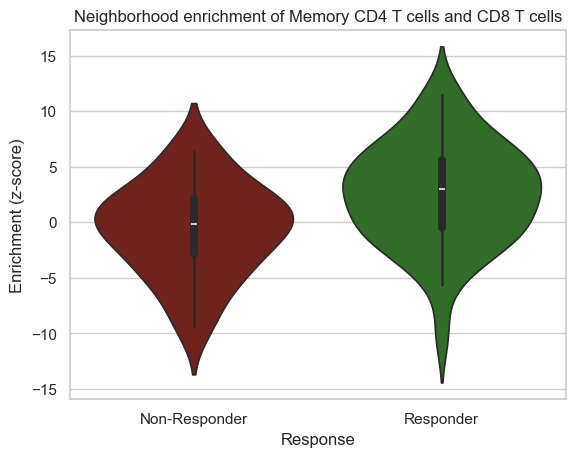

In [35]:
# create violin plots for the enrichment of the different cell types

ax = sns.violinplot(
    x='Response',
    y='enrichment_CD4_CD8',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of Memory CD4 T cells and CD8 T cells')
ax.set_ylabel('Enrichment (z-score)')



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2900694341.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

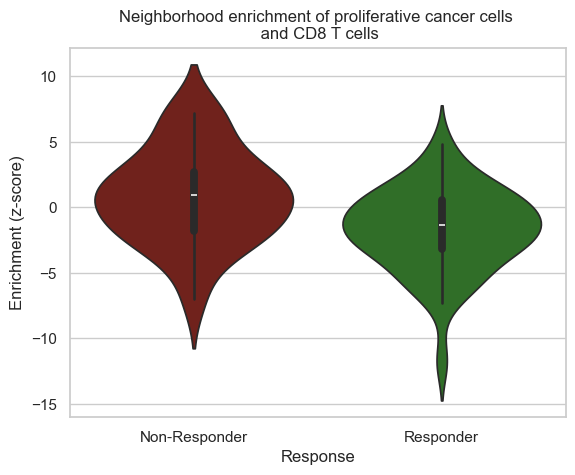

In [36]:



ax = sns.violinplot(
    x='Response',
    y='enrichment_CD8_cancerprolif',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of proliferative cancer cells \n and CD8 T cells')
ax.set_ylabel('Enrichment (z-score)')

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1470502268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

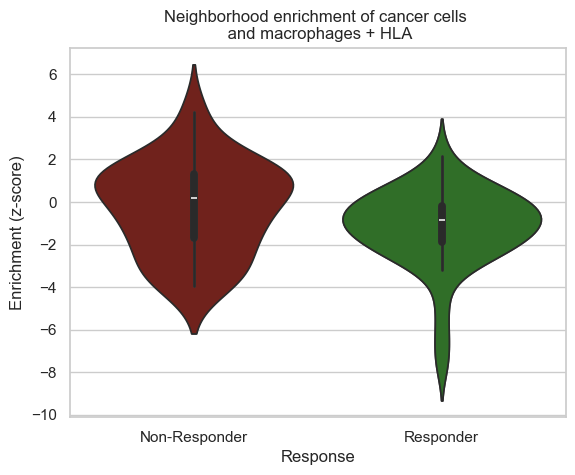

In [37]:
sns.violinplot(
    x='Response',
    y='enrichment_cancer_macroHLA',
    data=pretreat_metadata,
    inner='box'  # or 'point' or None
)



ax = sns.violinplot(
    x='Response',
    y='enrichment_cancer_macroHLA',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of cancer cells \n and macrophages + HLA')
ax.set_ylabel('Enrichment (z-score)')


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/2594614246.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

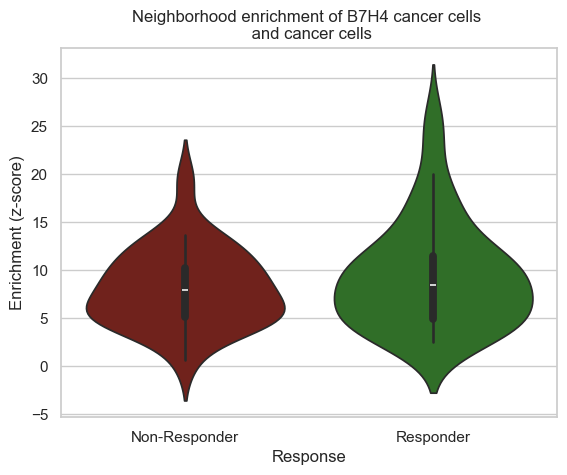

In [38]:




ax = sns.violinplot(
    x='Response',
    y='enrichment_b7h4_cancer',
    data=pretreat_metadata,
    inner='box',  # or 'point' or None
    palette=palette_response,
    saturation = 1
)


ax.set_xlabel("Response")
ax.set_title('Neighborhood enrichment of B7H4 cancer cells \n and cancer cells')
ax.set_ylabel('Enrichment (z-score)')



In [39]:
# now we do the same for the non-responders, generating pairwise information for some pairs of cell types and adding it to the nonresp_metadata dataframe
#“Macrophage”, “Memory CD4 T cell”
#“Antigen presenting cell”, “Regulatory T cell”
#“Monocyte”, “B cell + HLA”
#“Cancer cell Prol”, “CD8 T cell”
#“Fibroblast”, “Macrophage"

nonresp_metadata['enrichment_macro_CD4'] = gen_pairwise_info("Macrophage", "Memory CD4 T cell",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_APC_Treg'] = gen_pairwise_info("Antigen presenting cell", "Regulatory T cell",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_mono_BHLA'] = gen_pairwise_info("Monocyte", "B cell + HLA",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_cancerprol_CD8'] = gen_pairwise_info("Cancer cell Prol", "CD8 T cell",nonresp_dict, neighbors_nonresponders)
nonresp_metadata['enrichment_macro_fibro'] = gen_pairwise_info("Macrophage", "Fibroblast",nonresp_dict, neighbors_nonresponders)



NULL
LEAP001


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1268743387.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonresp_metadata['enrichment_macro_CD4'] = gen_pairwise_info("Macrophage", "Memory CD4 T cell",nonresp_dict, neighbors_nonresponders)
/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1268743387.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nonresp_metadata['enrichment_APC_Treg'] = gen_pairwise_info("Antigen presenting cell", "Regulatory T cell",nonresp_dict, n

In [40]:
nonresp_metadata.columns

Index(['Biopsy_(Core/Resection)', 'FORCE_cycle',
       'Sample_Type_(pre/post treatment)', 'NACT_Treatment _Group',
       'Response_pCR', 'RCB_Scores', 'RCB_Group', 'Tissue_Format',
       'Extreme_NR', 'FORCE', 'Response', 'Patient_ID', 'Stain_Batch',
       'enrichment_macro_CD4', 'enrichment_APC_Treg', 'enrichment_mono_BHLA',
       'enrichment_cancerprol_CD8', 'enrichment_macro_fibro'],
      dtype='object')

In [41]:
pre_color = "#D9C454" #np.array([217, 196,84])/255
post_color = "#711F74" # np.array([113, 31,116])/255

In [42]:
# make a seaborn palette with these two colors
palette_prepost = sns.color_palette([pre_color, post_color])

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/3814957245.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

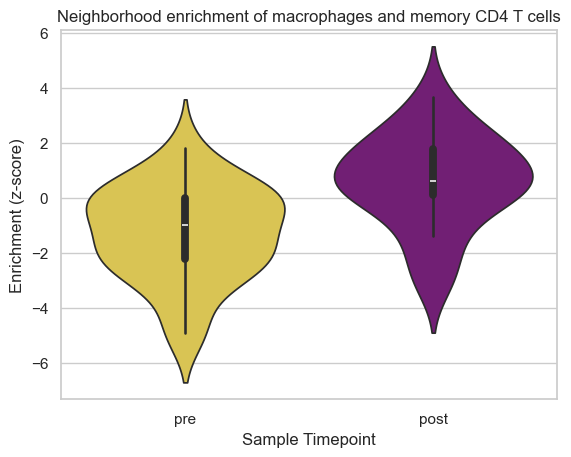

In [43]:
ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_macro_CD4',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1,
)

ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of macrophages and memory CD4 T cells')
ax.set_ylabel('Enrichment (z-score)')

/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1013864631.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

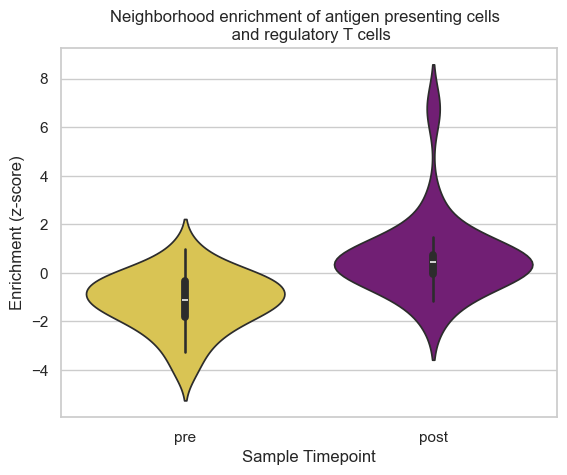

In [44]:
ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_APC_Treg',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of antigen presenting cells  \n and regulatory T cells')
ax.set_ylabel('Enrichment (z-score)')



/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1062261472.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

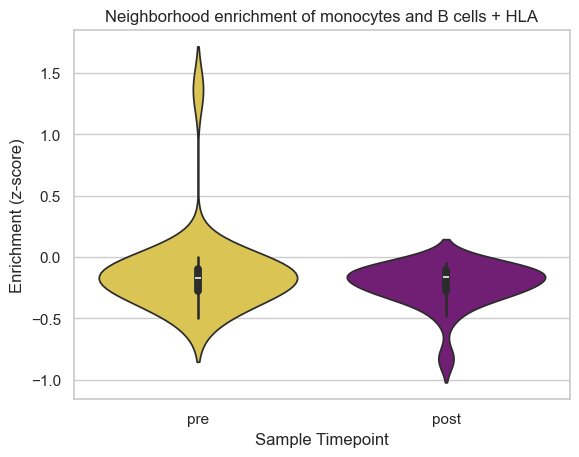

In [45]:

ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_mono_BHLA',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of monocytes and B cells + HLA')
ax.set_ylabel('Enrichment (z-score)')


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/4016252228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

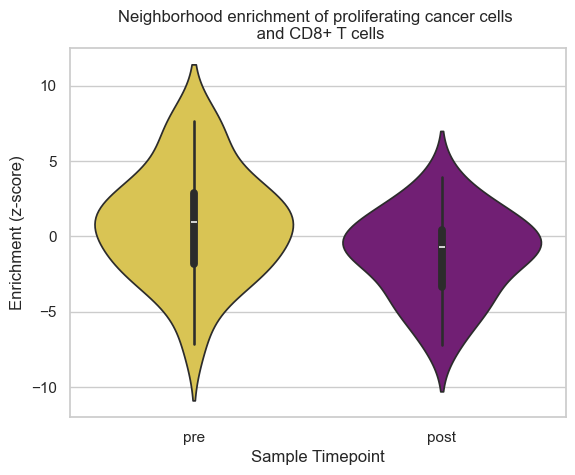

In [46]:

ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_cancerprol_CD8',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of proliferating cancer cells \n and CD8+ T cells')
ax.set_ylabel('Enrichment (z-score)')


/var/folders/92/tvn4jggs62qb78rd70twcy7w0000gn/T/ipykernel_18035/1368821517.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


Text(0, 0.5, 'Enrichment (z-score)')

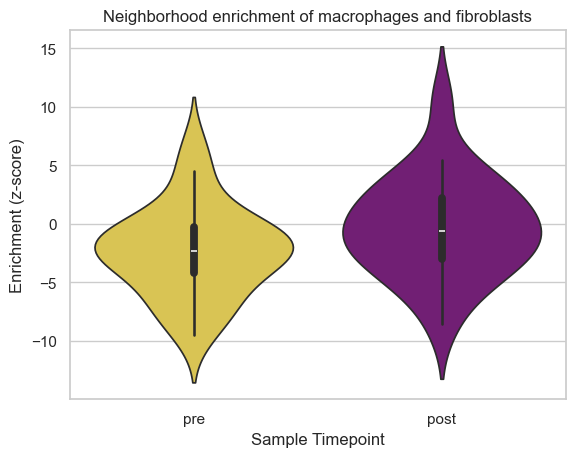

In [47]:

ax = sns.violinplot(
    x='Sample_Type_(pre/post treatment)',
    y='enrichment_macro_fibro',
    data=nonresp_metadata,
    inner='box',  # or 'point' or None
    palette=palette_prepost,
    saturation = 1
)


ax.set_xlabel("Sample Timepoint")
ax.set_title('Neighborhood enrichment of macrophages and fibroblasts')
ax.set_ylabel('Enrichment (z-score)')


In [48]:
# save the metadata with the enrichment information to csv files
nonresp_metadata.to_csv("nonresponder_df.csv")

In [49]:
pretreat_metadata.to_csv("pretreat_df.csv")

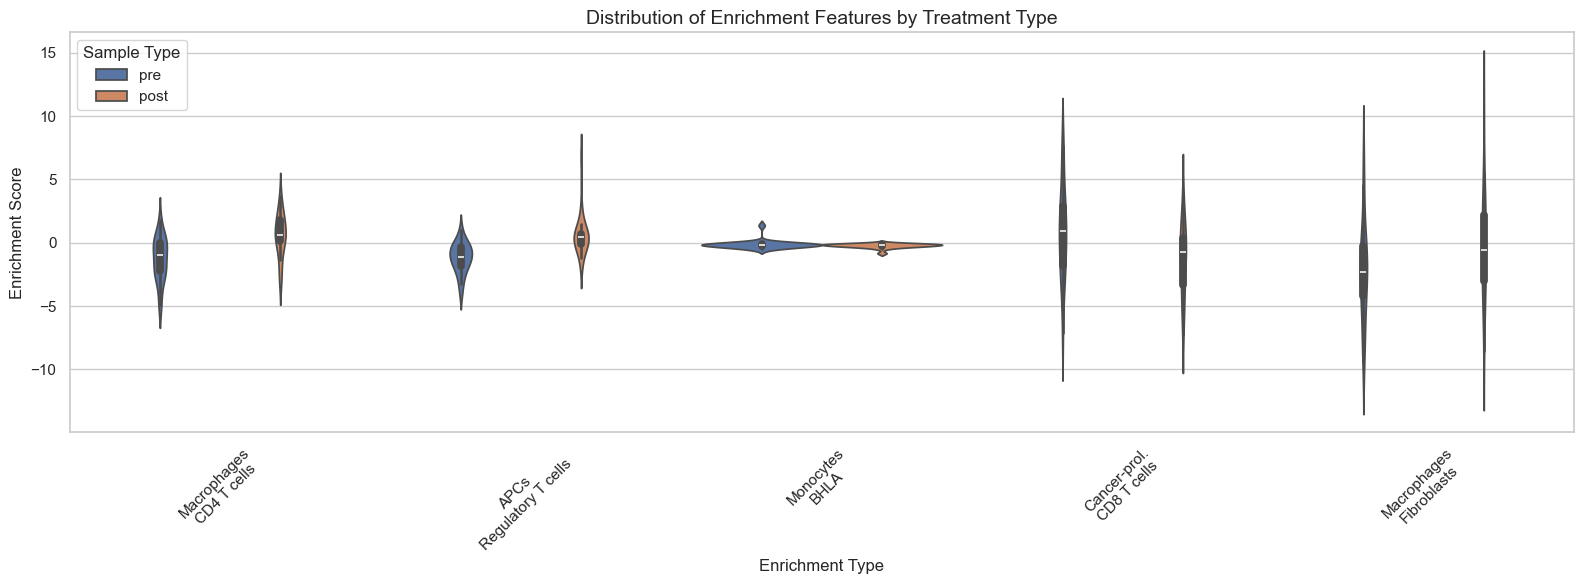

In [50]:
# plot violin plots for multiple pairs of cell types in a single plot
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your CSV file
df = pd.read_csv('nonresponder_df.csv')  # Make sure the file path is correct

# Melt the DataFrame for Seaborn
melted_df = df.melt(
    id_vars='Sample_Type_(pre/post treatment)',
    value_vars=[
        'enrichment_macro_CD4',
        'enrichment_APC_Treg',
        'enrichment_mono_BHLA',
        'enrichment_cancerprol_CD8',
        'enrichment_macro_fibro'
    ],
    var_name='Enrichment_Type',
    value_name='Value'
)

# Optional: Rename enrichment types for better readability
label_map = {
    'enrichment_macro_CD4': 'Macrophages\nCD4 T cells',
    'enrichment_APC_Treg': 'APCs\nRegulatory T cells',
    'enrichment_mono_BHLA': 'Monocytes\nBHLA',
    'enrichment_cancerprol_CD8': 'Cancer-prol.\nCD8 T cells',
    'enrichment_macro_fibro': 'Macrophages\nFibroblasts'
}

melted_df['Enrichment_Type'] = melted_df['Enrichment_Type'].map(label_map)

# Plot
plt.figure(figsize=(16, 6))
sns.violinplot(
    x='Enrichment_Type',
    y='Value',
    hue='Sample_Type_(pre/post treatment)',
    data=melted_df,
    #split=True
)

# Customize titles and labels
plt.title('Distribution of Enrichment Features by Treatment Type', fontsize=14)
plt.xlabel('Enrichment Type', fontsize=12)
plt.ylabel('Enrichment Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Sample Type')
plt.show()


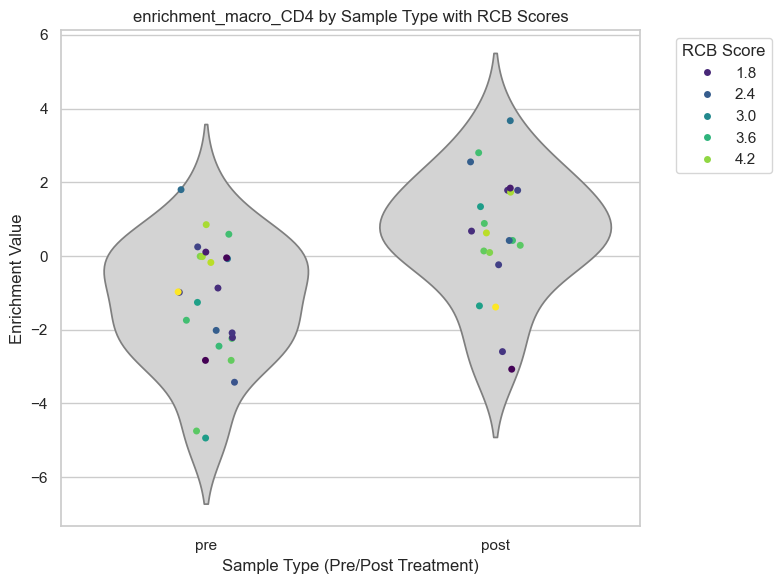

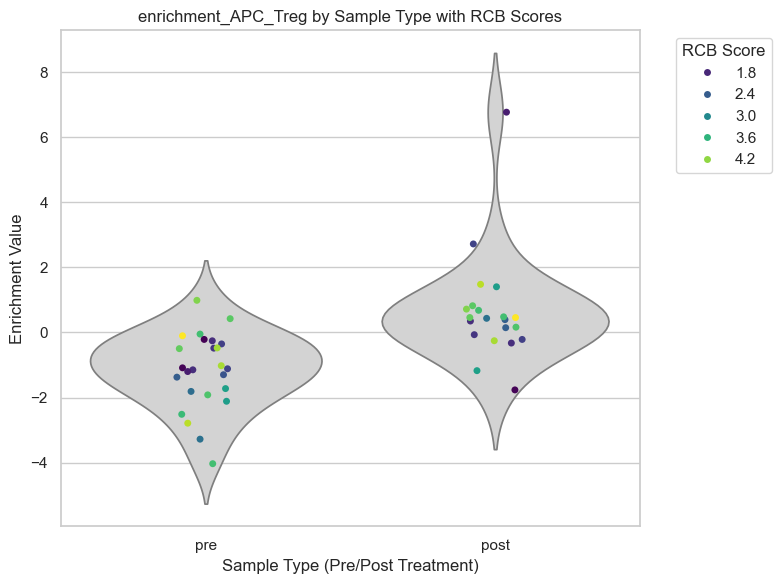

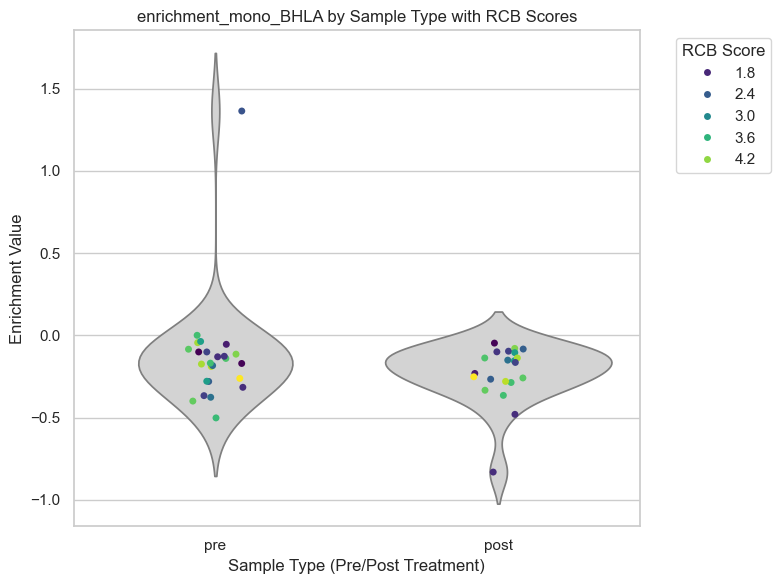

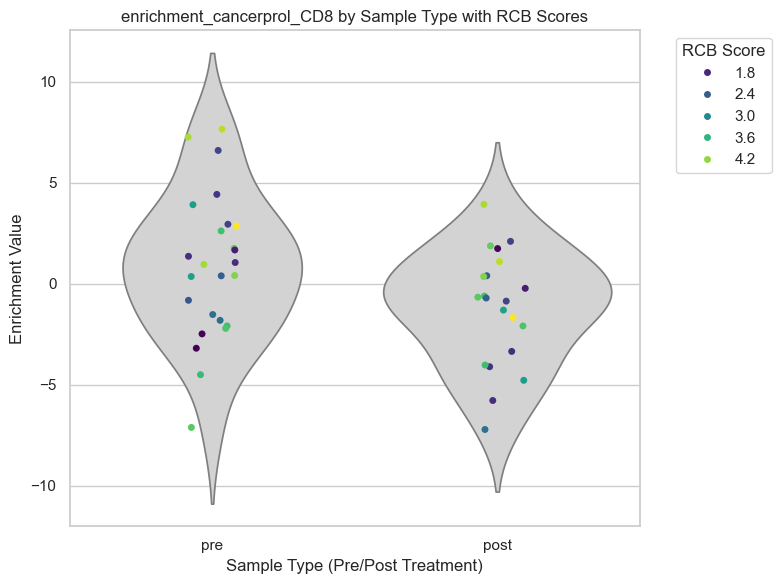

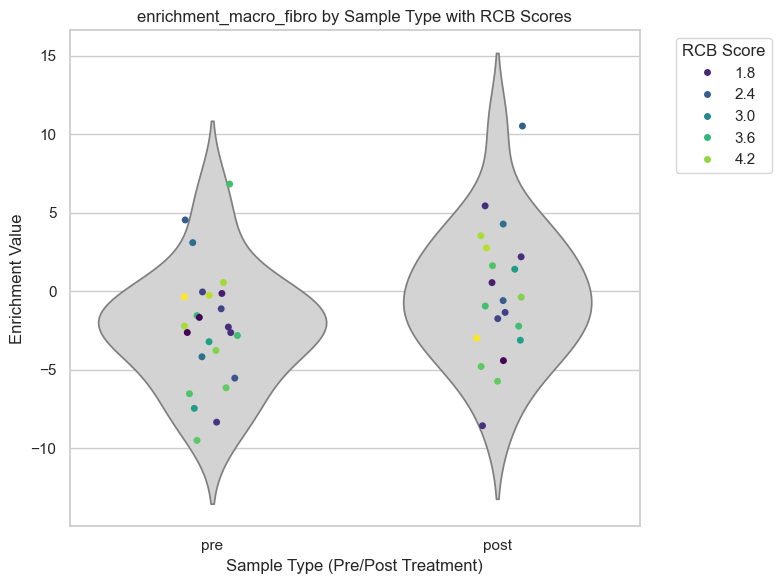

In [51]:
# plot violin plots for each pair of cell types, with individual data points overlayed, colored by RCB_Scores
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("nonresponder_df.csv")

# List of enrichment columns
enrichment_columns = [
    "enrichment_macro_CD4",
    "enrichment_APC_Treg",
    "enrichment_mono_BHLA",
    "enrichment_cancerprol_CD8",
    "enrichment_macro_fibro"
]

# Loop through each enrichment column and plot separately
for column in enrichment_columns:
    plt.figure(figsize=(8, 6))
    
    # Violin plot split by Sample_Type_(pre/post treatment)
    sns.violinplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=column,
        inner=None,
        color="lightgray"
    )
    
    # Overlay individual data points colored by RCB_Scores
    sns.stripplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=column,
        hue="RCB_Scores",
        palette="viridis",
        dodge=False,
        jitter=True,
        size=5
    )

    # Customize plot
    plt.title(f"{column} by Sample Type with RCB Scores")
    plt.xlabel("Sample Type (Pre/Post Treatment)")
    plt.ylabel("Enrichment Value")
    plt.legend(title="RCB Score", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


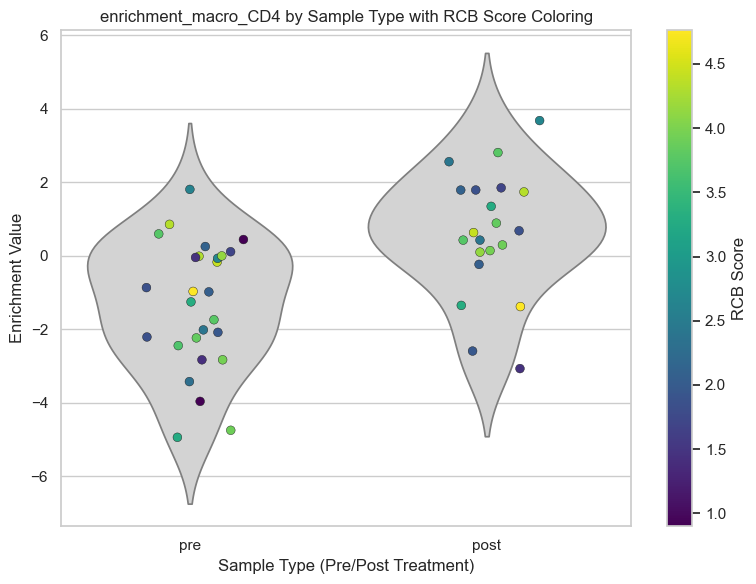

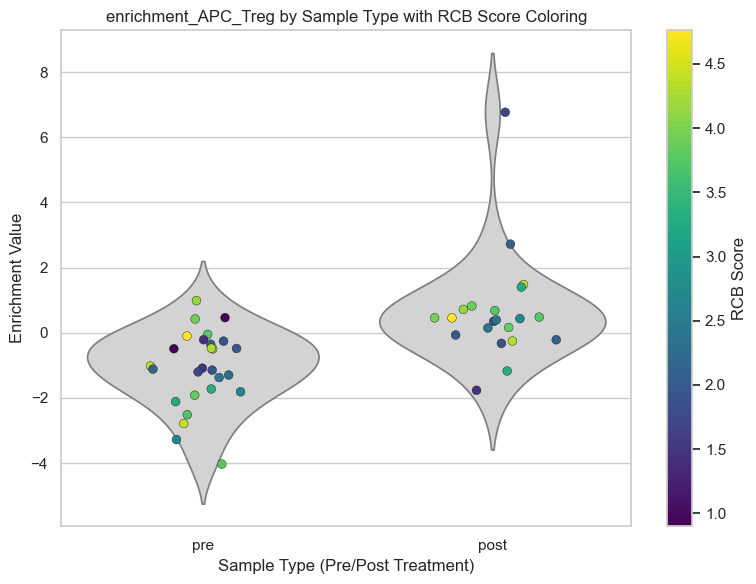

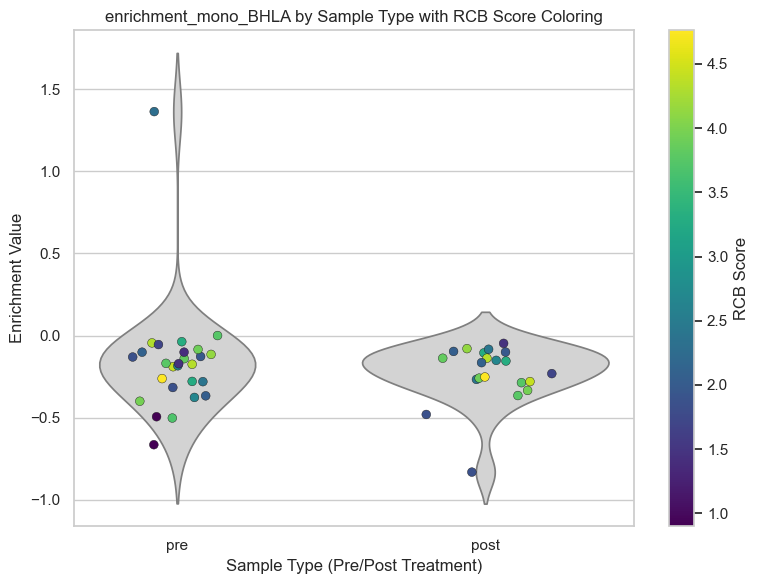

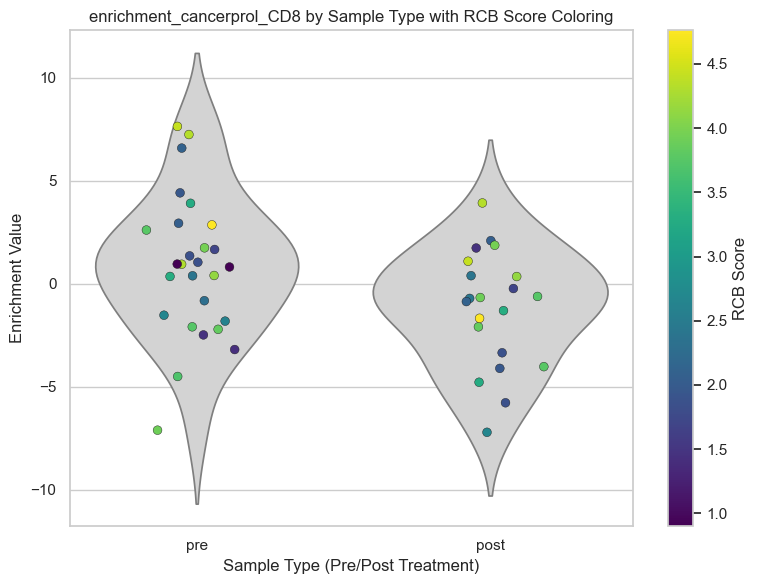

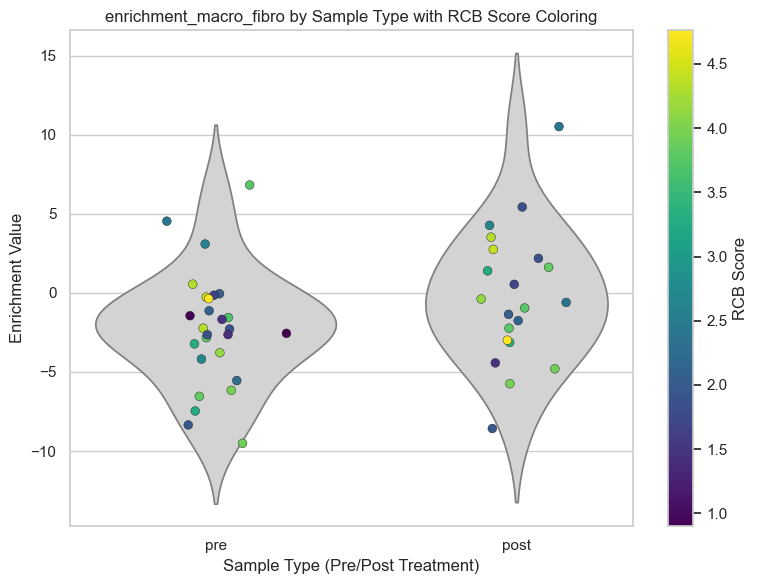

In [374]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_csv("nonresponder_df.csv")

# Define enrichment columns
enrichment_columns = [
    "enrichment_macro_CD4",
    "enrichment_APC_Treg",
    "enrichment_mono_BHLA",
    "enrichment_cancerprol_CD8",
    "enrichment_macro_fibro"
]

# Normalize RCB scores for consistent color mapping
rcb_values = df["RCB_Scores"]
vmin, vmax = rcb_values.min(), rcb_values.max()
norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis

# Plot loop
for col in enrichment_columns:
    plt.figure(figsize=(8, 6))
    
    # Violin plot
    sns.violinplot(
        data=df,
        x="Sample_Type_(pre/post treatment)",
        y=col,
        inner=None,
        color="lightgray"
    )

    # Overlay colored dots manually
    x_labels = df["Sample_Type_(pre/post treatment)"].unique()
    for i, group in enumerate(x_labels):
        subset = df[df["Sample_Type_(pre/post treatment)"] == group]
        x_coords = np.random.normal(i, 0.08, size=len(subset))  # jitter
        y_coords = subset[col].values
        colors = cmap(norm(subset["RCB_Scores"].values))
        plt.scatter(x_coords, y_coords, c=colors, s=40, edgecolor="k", linewidth=0.3)

    # Colorbar (now explicitly tied to current axes)
    ax = plt.gca()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("RCB Score")

    # Final plot formatting
    plt.title(f"{col} by Sample Type with RCB Score Coloring")
    plt.xlabel("Sample Type (Pre/Post Treatment)")
    plt.ylabel("Enrichment Value")
    plt.tight_layout()
    plt.show()
